# Day 1 · Batch 1·2·3 EDA 및 모델 전략

## 비즈니스 문제 정의

ESS 배터리가 예상보다 일찍 수명을 다하면 갑작스러운 가동 중단과 교체 비용이 발생하고 전력 공급 안정성이 저하될 수 있다. 따라서 초기 충·방전 데이터로 배터리의 최종 수명을 예측하여 조기 불량 셀을 식별하고 예방 교체 시점을 계획하고자 한다.

이를 통해 과도하게 이른 교체와 용량 저하 상태에서의 장기 운용 위험을 함께 줄이는 것이 분석의 목적이다.

## 초기 가설과 분석 질문

### 핵심 가설

충전 속도가 높을수록 배터리의 Cycle Life가 짧아지는 음의 관계가 있을 것으로 예상한다.

- **H₀:** 유효 C-rate와 Cycle Life의 Spearman 상관계수는 0이다.
- **H₁:** 유효 C-rate와 Cycle Life의 Spearman 상관계수는 0이 아니다. 연구의 예상 방향은 C-rate가 높을수록 수명이 짧아지는 음(-)의 관계이다.

### 추가 분석 질문

충전 속도가 같더라도 셀마다 수명이 다르므로, 충전 속도만으로 설명되지 않는 차이를 ΔQ(V), 초기 온도, 내부저항에서 확인한다.

관찰 데이터이므로 관계가 확인되더라도 충전 속도나 온도를 수명 감소의 직접적인 원인으로 단정하지 않는다.

## Day 1 분석 목표와 범위

세 배치의 특성을 동일한 기준으로 비교하고, 초기 100사이클 데이터에서 Cycle Life 예측에 유용한 신호를 선별하여 회귀모델 전략을 수립한다.

- **Day 1 EDA:** Batch 1·2·3 전체
- **Day 2 개발:** Batch 1 학습·검증, Batch 2 최종 테스트
- **Batch 3 모델 평가:** 추가 검증 항목
- **제외:** `2018-04-03 varcharge`는 별도 충전 최적화 실험 데이터
- **목표변수:** 연속형 `cycle_life` → 회귀
- **업무 의미:** `cycle_life`는 방전용량이 초기 기준의 80%에 도달할 때까지의 사이클 수이며, ESS 교체 시점을 나타내는 기준으로 해석한다.

## 1. 입력 데이터와 공통 분석 기준

과제에서 지정한 Batch 1·2·3을 동일한 기준으로 비교한다. `2018-04-03 varcharge`는 별도 충전 최적화 실험이므로 분석 범위에서 제외한다.

| 구분 | 내용 | 분석에서의 역할 |
|---|---|---|
| 분석 단위 | 독립 배터리 셀 | 한 셀을 하나의 표본으로 사용 |
| 원시 입력 | 충전 정책, 사이클별 방전용량·온도·내부저항, Cycle 10·100 Q(V) | 초기 수명 신호와 열화 현상 확인 |
| 목표변수(y) | `cycle_life` | 방전용량이 초기 기준의 80%에 도달할 때까지의 사이클 수 |
| 후보 피처(X) | ΔQ(V) 분산, 유효 C-rate, 초기 평균 온도, 초기 내부저항 | Cycle Life 회귀 예측 |

### 변수 정의

| 변수 | 역할 | 데이터 유형 | 정의 및 계산 기준 |
|---|---|---|---|
| `cycle_life` | 목표변수 y | 수치형·이산형 | 방전용량이 초기 기준의 80%에 도달할 때까지의 사이클 수 |
| `effective_c_rate_to_80pct` | 핵심 설명변수 X | 연속형 | 두 단계 충전시간을 합산하여 80% SOC까지의 유효 충전 속도로 환산 |
| `log10_deltaq_variance` | 후보 피처 X | 연속형 | Cycle 100과 Cycle 10의 Q(V) 차이 분산에 log10 적용 |
| `mean_Tavg_first100` | 후보 피처 X | 연속형 | 초기 1~100사이클의 평균 온도 |
| `median_IR_first100` | 후보 피처 X | 연속형 | 0값을 제외한 초기 1~100사이클 내부저항 중앙값 |
| `batch` | 그룹 변수 | 범주형 | 데이터 수집 시점과 실험 배치를 구분 |
| `charging_policy` | 그룹·조건 변수 | 범주형 | 셀에 적용된 두 단계 충전 정책 |
| `cell_id` | 식별자 | 명목형 | 각 배치 안에서 배터리 셀을 구분하는 번호 |
| `cycle` | 시간 순서 변수 | 순서형·이산형 | 각 배터리의 충·방전 반복 순서 |
| `QDischarge` | 열화 분석 변수 | 연속형 시계열 | 사이클별 방전용량 |

### 변수 사용 기준

- 한 배터리 셀을 하나의 독립 표본으로 사용한다.
- `cycle_life`는 사이클 수로 측정되는 이산형 변수이지만, 구체적인 교체 시점을 예측하기 위해 회귀의 연속형 목표값으로 처리한다.
- `batch`, `charging_policy`, `cell_id`는 데이터 구분과 검증 분할에 사용하며 숫자 자체의 크기에는 의미를 부여하지 않는다.
- `QDischarge`는 열화곡선을 확인하는 시계열 변수이며 모델에 원시 상태로 직접 입력하지 않는다.
- Knee Point는 전체 수명곡선이 필요한 미래정보이므로 초기 예측 피처에서 제외한다.
- 목표값이 없는 셀은 개수를 보고하되 Cycle Life 기반 EDA와 지도학습에서는 제외한다.


In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "archive"
BATCH_FILES = {
    "Batch 1": DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch 2": DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch 3": DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
for batch_name, file_path in BATCH_FILES.items():
    assert file_path.is_file(), f"{batch_name} 파일을 찾을 수 없습니다: {file_path}"

display(pd.DataFrame([
    {"batch": name, "file": path.name, "size_GB": path.stat().st_size / 1024**3}
    for name, path in BATCH_FILES.items()
]).round(2))

,batch,file,size_GB
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,2.82
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,1.88
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,3.01


### 1-1. 세 배치 구조 확인

In [2]:
structure_rows = []
for batch_name, file_path in BATCH_FILES.items():
    with h5py.File(file_path, "r") as f:
        batch_group = f["batch"]
        life_values = []
        voltage_specs = set()
        for cell_id in range(batch_group["cycle_life"].shape[0]):
            life_values.append(float(np.asarray(
                f[batch_group["cycle_life"][cell_id, 0]]
            ).squeeze()))
            voltage = np.asarray(f[batch_group["Vdlin"][cell_id, 0]]).reshape(-1)
            voltage_specs.add((len(voltage), float(voltage.min()), float(voltage.max())))
        structure_rows.append({
            "batch": batch_name,
            "raw_cells": len(life_values),
            "valid_cycle_life": int(np.isfinite(life_values).sum()),
            "missing_cycle_life": int(np.isnan(life_values).sum()),
            "fields": ", ".join(batch_group.keys()),
            "Vdlin_specs": str(sorted(voltage_specs)),
        })
structure = pd.DataFrame(structure_rows)
display(structure)

,batch,raw_cells,valid_cycle_life,missing_cycle_life,fields,Vdlin_specs
0,Batch 1,46,46,0,"Vdlin, barcode, channel_id, cycle_life, cycles...","[(1000, 2.0, 3.5)]"
1,Batch 2,47,39,8,"Vdlin, barcode, channel_id, cycle_life, cycles...","[(1000, 2.0, 3.5)]"
2,Batch 3,46,44,2,"Vdlin, barcode, channel_id, cycle_life, cycles...","[(1000, 2.0, 3.5)]"


### 1-2. 배터리별 표와 사이클별 표 생성

- 배터리별 표의 한 행은 하나의 독립 배터리 셀이다.
- 사이클별 표는 한 셀의 반복 측정값이므로 이를 독립 표본처럼 분할하지 않는다.
- Batch 2에서 목표 수명 이후에도 기록된 사이클은 `cycle_life`까지만 사용한다.

In [3]:
batch_cell_rows = []
batch_summary_tables = []

for batch_name, file_path in BATCH_FILES.items():
    with h5py.File(file_path, "r") as f:
        batch_group = f["batch"]
        for cell_id in range(batch_group["cycle_life"].shape[0]):
            life = float(np.asarray(f[batch_group["cycle_life"][cell_id, 0]]).squeeze())
            policy = "".join(chr(int(x)) for x in np.asarray(
                f[batch_group["policy_readable"][cell_id, 0]]
            ).ravel())
            batch_cell_rows.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "charging_policy": policy,
                "cycle_life": life,
            })
            if np.isfinite(life):
                summary_group = f[batch_group["summary"][cell_id, 0]]
                values = {key: np.asarray(summary_group[key]).reshape(-1)
                          for key in summary_group}
                table = pd.DataFrame(values)
                table.insert(0, "cell_id", cell_id)
                table.insert(0, "batch", batch_name)
                table = table[table["cycle"] <= life].copy()
                batch_summary_tables.append(table)

batch_cells_all = pd.DataFrame(batch_cell_rows)
batch_cells = batch_cells_all.dropna(subset=["cycle_life"]).copy()
batch_summary = pd.concat(batch_summary_tables, ignore_index=True)

print("배터리별 유효 표:", batch_cells.shape)
print("사이클별 요약 표:", batch_summary.shape)
display(batch_cells.groupby("batch").agg(
    valid_cells=("cell_id", "count"),
    policies=("charging_policy", "nunique"),
    minimum_life=("cycle_life", "min"),
    median_life=("cycle_life", "median"),
    maximum_life=("cycle_life", "max"),
))

배터리별 유효 표: (129, 4)
사이클별 요약 표: (107456, 10)


,valid_cells,policies,minimum_life,median_life,maximum_life
batch,,,,,
Batch 1,46,23,534.0,858.5,1227.0
Batch 2,39,12,392.0,472.0,1186.0
Batch 3,44,8,541.0,1005.5,1935.0


### 1-3. 데이터 품질 점검

- Batch 2의 내부저항(`IR`) 0값은 **4,286/22,064행(19.43%)**으로 Batch 1의 65행보다 많다. 0값을 실제 저항으로 해석하지 않고 결측성 측정값으로 제외한다.
- Batch 2는 IR 측정 누락이 많아 배치 간 내부저항 비교의 신뢰도가 낮다. 따라서 IR은 초기 핵심 피처에서 제외하고, Day 2에서 사용하려면 결측 처리와 민감도 검증을 먼저 수행한다.

In [4]:
quality_rows = []
for batch_name in BATCH_FILES:
    cell_all = batch_cells_all[batch_cells_all["batch"] == batch_name]
    summary_part = batch_summary[batch_summary["batch"] == batch_name]
    quality_rows.append({
        "batch": batch_name,
        "missing_target_cells": int(cell_all["cycle_life"].isna().sum()),
        "summary_rows": len(summary_part),
        "summary_missing_values": int(summary_part.isna().sum().sum()),
        "duplicate_cell_cycle": int(summary_part.duplicated(["cell_id", "cycle"]).sum()),
        "IR_equal_0": int(summary_part["IR"].eq(0).sum()),
        "QDischarge_below_0": int(summary_part["QDischarge"].lt(0).sum()),
    })
quality = pd.DataFrame(quality_rows)
display(quality)
for batch_name, group in batch_cells_all.groupby("batch"):
    missing_ids = group.loc[group["cycle_life"].isna(), "cell_id"].tolist()
    print(f"{batch_name} 목표값 결측 cell_id: {missing_ids}")

,batch,missing_target_cells,summary_rows,summary_missing_values,duplicate_cell_cycle,IR_equal_0,QDischarge_below_0
0,Batch 1,0,38811,0,0,65,0
1,Batch 2,8,22064,0,0,4286,0
2,Batch 3,2,46581,0,0,0,0


Batch 1 목표값 결측 cell_id: []
Batch 2 목표값 결측 cell_id: [22, 23, 35, 36, 37, 38, 39, 40]
Batch 3 목표값 결측 cell_id: [23, 32]


### 1-4. 초기 피처 생성

예측 시점 이후의 정보를 사용하지 않도록 초기 100사이클 안에서 계산 가능한 피처만 생성한다.

| 피처 | 계산 기준 | 선택 이유 |
|---|---|---|
| `log10_deltaq_variance` | Cycle 100 Q(V) − Cycle 10 Q(V)의 분산에 log10 적용 | 초기 곡선 변화의 크기 요약 |
| `effective_c_rate_to_80pct` | 두 단계 충전시간을 합산해 80% SOC까지의 유효 속도로 환산 | 서로 다른 충전 정책을 하나의 수치로 비교 |
| `mean_Tavg_first100` | 초기 1~100사이클 평균 온도 | 열 발생과 수명 관계 확인 |
| `median_IR_first100` | 0을 제외한 초기 1~100사이클 내부저항 중앙값 | 측정 오류 영향을 줄여 저항 신호 확인 |

Knee Point는 전체 수명곡선이 필요한 값이므로 EDA 설명에만 사용하고 예측 피처에서는 제외한다.

In [5]:
policy_parts = batch_cells["charging_policy"].str.extract(
    r"(?P<c1>[0-9.]+)C\((?P<switch_soc>[0-9.]+)%\)-(?P<c2>[0-9.]+)C"
).astype(float)
batch_charging = pd.concat(
    [batch_cells.reset_index(drop=True), policy_parts.reset_index(drop=True)], axis=1
)
switch_fraction = batch_charging["switch_soc"] / 100
batch_charging["effective_c_rate_to_80pct"] = 0.8 / (
    switch_fraction / batch_charging["c1"] +
    (0.8 - switch_fraction) / batch_charging["c2"]
)

batch_deltaq_rows = []
deltaq_curves = {}
for batch_name, file_path in BATCH_FILES.items():
    valid_ids = batch_cells.loc[batch_cells["batch"] == batch_name, "cell_id"].astype(int)
    with h5py.File(file_path, "r") as f:
        batch_group = f["batch"]
        for cell_id in valid_ids:
            cycles_group = f[batch_group["cycles"][cell_id, 0]]
            q10 = np.asarray(f[cycles_group["Qdlin"][9, 0]]).reshape(-1)
            q100 = np.asarray(f[cycles_group["Qdlin"][99, 0]]).reshape(-1)
            voltage = np.asarray(f[batch_group["Vdlin"][cell_id, 0]]).reshape(-1)
            delta_q = q100 - q10
            variance = float(np.var(delta_q, ddof=1))
            deltaq_curves[(batch_name, cell_id)] = (voltage, delta_q)
            batch_deltaq_rows.append({
                "batch": batch_name,
                "cell_id": cell_id,
                "log10_deltaq_variance": np.log10(variance),
            })
batch_deltaq = pd.DataFrame(batch_deltaq_rows)

batch_early_rows = []
for (batch_name, cell_id), group in batch_summary.groupby(["batch", "cell_id"]):
    early = group[(group["cycle"] >= 1) & (group["cycle"] <= 100)]
    valid_ir = early.loc[early["IR"] > 0, "IR"]
    batch_early_rows.append({
        "batch": batch_name,
        "cell_id": int(cell_id),
        "mean_Tavg_first100": float(early["Tavg"].mean()),
        "max_Tmax_first100": float(early["Tmax"].max()),
        "median_IR_first100": float(valid_ir.median()),
    })
batch_early = pd.DataFrame(batch_early_rows)

batch_features = (
    batch_cells[["batch", "cell_id", "charging_policy", "cycle_life"]]
    .merge(batch_deltaq, on=["batch", "cell_id"])
    .merge(batch_charging[["batch", "cell_id", "effective_c_rate_to_80pct"]],
           on=["batch", "cell_id"])
    .merge(batch_early, on=["batch", "cell_id"])
)
display(batch_features.head())

,batch,cell_id,charging_policy,cycle_life,log10_deltaq_variance,effective_c_rate_to_80pct,mean_Tavg_first100,max_Tmax_first100,median_IR_first100
0,Batch 1,0,3.6C(80%)-3.6C,1190.0,-5.014427,3.6,31.287710,35.994705,0.016619
1,Batch 1,1,3.6C(80%)-3.6C,1179.0,-5.013525,3.6,31.017011,34.712265,0.016923
2,Batch 1,2,3.6C(80%)-3.6C,1177.0,-4.736565,3.6,31.164788,35.127342,0.016769
3,Batch 1,3,4C(80%)-4C,1226.0,-4.442179,4.0,29.642777,31.691414,0.016315
4,Batch 1,4,4C(80%)-4C,1227.0,-4.647309,4.0,31.134395,35.651741,0.016677


---

# 탐색적 데이터 분석(EDA)

모델링에 앞서 Batch별 Cycle Life 분포와 배터리 열화 패턴을 확인하고, 초기 측정 신호와 최종 수명의 관계를 탐색한다.

EDA에서는 다음 내용을 확인한다.

1. Batch별 Cycle Life의 중심, 산포, 장·단수명 비율과 이상치
2. 사이클이 증가할 때 방전용량이 감소하는 형태와 Knee Point
3. 초기 ΔQ(V) 변화가 장수명 셀과 단수명 셀을 구분하는지
4. 충전 조건인 유효 C-rate와 Cycle Life의 관계
5. 초기 온도·내부저항을 포함한 피처별 상관관계와 멀티콜리니어리티

시각적으로 발견한 패턴은 중앙값, IQR, 비율, Spearman 상관계수와 p-value를 통해 수치로 확인한다. EDA에서 확인한 상관관계는 인과관계를 의미하지 않으며, 최종 피처의 가치는 모델의 교차검증과 Hold-out 성능으로 판단한다.

# Question 1. Cycle Life 분포는 어떻게 생겼는가?

150~2,300사이클의 공통 구간에서 Batch별 Histogram으로 분포 형태를 확인하고, 전체 유효 셀을 표시한 Box Plot으로 중앙값·사분위 범위·극단값을 비교한다. 장수명(>1,000)·단수명(<500) 비율과 최단수명 셀의 원인 후보도 함께 확인한다.

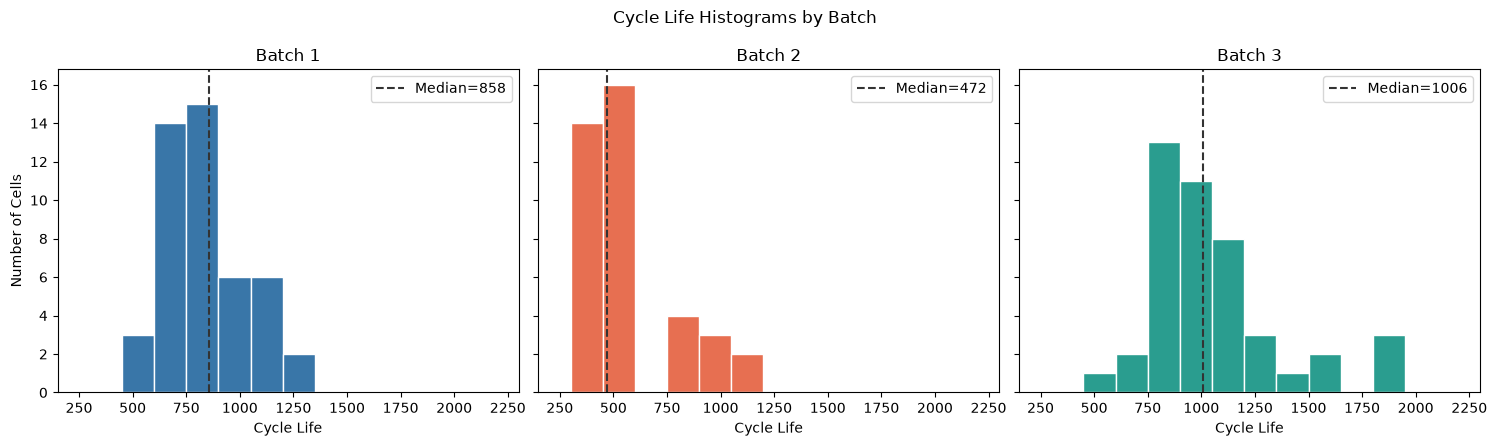

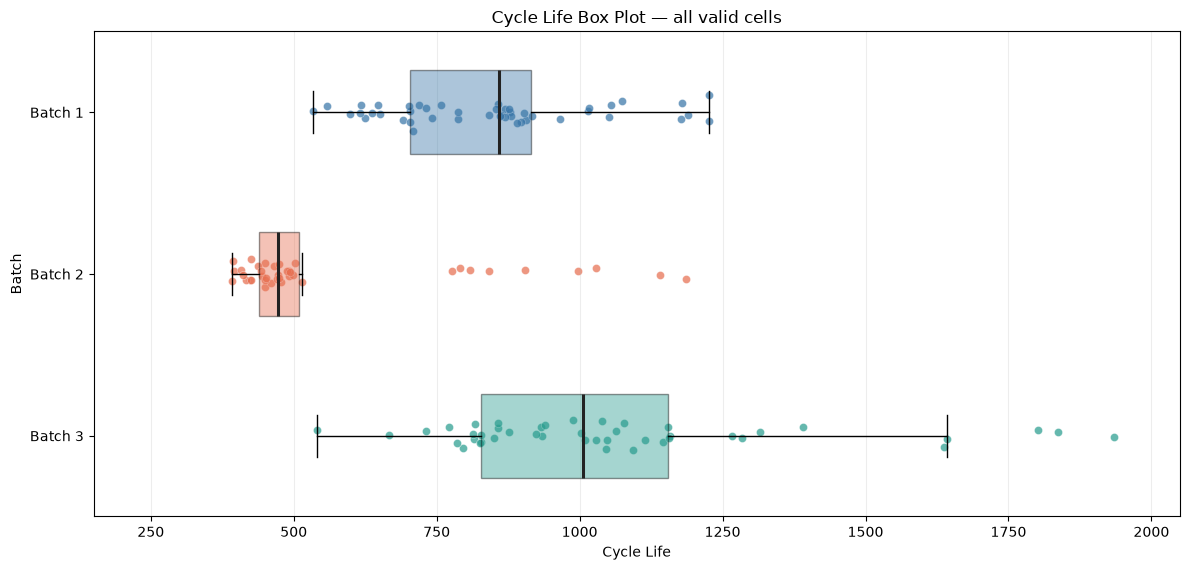

,valid_cells,minimum,q1,median,q3,mean,maximum,IQR,missing_target_cells,long_life_>1000_n,long_life_>1000_%,short_life_<500_n,short_life_<500_%
batch,,,,,,,,,,,,,
Batch 1,46,534.0,703.2,858.5,914.2,844.7,1227.0,211.0,0,10,21.7,0,0.0
Batch 2,39,392.0,439.5,472.0,508.5,565.7,1186.0,69.0,8,3,7.7,28,71.8
Batch 3,44,541.0,828.0,1005.5,1155.2,1059.7,1935.0,327.2,2,23,52.3,0,0.0


In [6]:
batch_distribution = batch_cells.groupby("batch")["cycle_life"].agg(
    valid_cells="count", minimum="min",
    q1=lambda s: s.quantile(0.25), median="median",
    q3=lambda s: s.quantile(0.75), mean="mean", maximum="max"
)
batch_distribution["IQR"] = batch_distribution["q3"] - batch_distribution["q1"]
batch_distribution["missing_target_cells"] = (
    batch_cells_all.groupby("batch")["cycle_life"].apply(lambda s: s.isna().sum())
)
batch_distribution["long_life_>1000_n"] = batch_cells.groupby("batch")["cycle_life"].apply(lambda s: (s > 1000).sum())
batch_distribution["long_life_>1000_%"] = batch_cells.groupby("batch")["cycle_life"].apply(lambda s: 100 * (s > 1000).mean())
batch_distribution["short_life_<500_n"] = batch_cells.groupby("batch")["cycle_life"].apply(lambda s: (s < 500).sum())
batch_distribution["short_life_<500_%"] = batch_cells.groupby("batch")["cycle_life"].apply(lambda s: 100 * (s < 500).mean())

bins = np.arange(150, 2351, 150)
colors = ["#3976A8", "#E76F51", "#2A9D8F"]
batch_order = list(BATCH_FILES)
box_values = [batch_cells.loc[batch_cells["batch"] == name, "cycle_life"].to_numpy()
              for name in batch_order]

# Histogram: Batch별 분포의 모양을 비교한다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (batch_name, group), color in zip(axes, batch_cells.groupby("batch"), colors):
    ax.hist(group["cycle_life"], bins=bins, color=color, edgecolor="white")
    ax.axvline(group["cycle_life"].median(), color="#333333", linestyle="--",
               label=f"Median={group['cycle_life'].median():.0f}")
    ax.set(title=batch_name, xlabel="Cycle Life", xlim=(150, 2300))
    ax.legend()
axes[0].set_ylabel("Number of Cells")
fig.suptitle("Cycle Life Histograms by Batch")
plt.tight_layout()
plt.show()

# Box Plot: 전체 셀의 중앙값, 사분위 범위, 극단값을 넓은 축에서 확인한다.
fig, ax = plt.subplots(figsize=(12, 5.8))
box = ax.boxplot(box_values, tick_labels=batch_order, orientation="horizontal",
                 patch_artist=True, showfliers=False, widths=0.52,
                 medianprops={"color": "#222222", "linewidth": 2.2})
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.42)
rng = np.random.default_rng(42)
for position, values, color in zip(range(1, 4), box_values, colors):
    jitter = rng.normal(0, 0.055, len(values))
    ax.scatter(values, np.full(len(values), position) + jitter,
               s=34, alpha=0.72, color=color, edgecolor="white", linewidth=0.35)
ax.set(xlabel="Cycle Life", ylabel="Batch",
       title="Cycle Life Box Plot — all valid cells", xlim=(150, 2050))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)
plt.tight_layout()
plt.show()

display(batch_distribution.round(1))

In [7]:
feature_medians = batch_features.groupby("batch").agg(
    median_cycle_life=("cycle_life", "median"),
    median_effective_c_rate=("effective_c_rate_to_80pct", "median"),
    median_log10_deltaq_variance=("log10_deltaq_variance", "median"),
    median_early_temperature=("mean_Tavg_first100", "median"),
).reset_index()
shortest_cells = batch_features.loc[
    batch_features.groupby("batch")["cycle_life"].idxmin()
].merge(feature_medians, on="batch")
display(shortest_cells[[
    "batch", "cell_id", "cycle_life", "charging_policy",
    "effective_c_rate_to_80pct", "median_effective_c_rate",
    "log10_deltaq_variance", "median_log10_deltaq_variance",
    "mean_Tavg_first100", "median_early_temperature",
]].round(3))

,batch,cell_id,cycle_life,charging_policy,effective_c_rate_to_80pct,median_effective_c_rate,log10_deltaq_variance,median_log10_deltaq_variance,mean_Tavg_first100,median_early_temperature
0,Batch 1,20,534.0,5.4C(80%)-5.4C,5.400,4.402,-3.367,-3.851,31.831,32.474
1,Batch 2,19,392.0,6C(60%)-3C,4.800,4.800,-3.292,-3.487,32.770,33.016
2,Batch 3,28,541.0,3.7C(31%)-5.9C-newstructure,4.795,4.802,-3.451,-4.175,35.695,34.111


### Question 1 — 해석 및 결론

#### 1. Batch별 Cycle Life 분포

Histogram과 Box Plot을 확인한 결과, 세 Batch의 Cycle Life 분포는 서로 다르게 나타났다.

- **Batch 1:** 중앙값은 858.5사이클이고 IQR은 211.0이다. 세 배치 중 중간 수준의 수명 분포를 보인다.
- **Batch 2:** 중앙값은 472.0사이클이고 유효 셀의 71.8%가 500사이클 미만이다. 대부분 단수명 구간에 집중되어 있지만 일부 셀은 1,000사이클 이상까지 분포한다.
- **Batch 3:** 중앙값은 1,005.5사이클이고 52.3%가 1,000사이클을 초과한다. 수명 수준은 가장 높지만 IQR도 327.2로 가장 커서 셀별 차이가 크다.

Box Plot의 점은 이상치만 표시한 것이 아니라 Batch별 전체 유효 셀이다. 따라서 박스에서 멀리 떨어진 점도 제거 대상이 아니라 실제 셀 간 수명 차이를 나타낸다.

#### 2. 최단수명 셀의 특징

- **Batch 1 Cell 20:** Cycle Life는 534사이클이며, 유효 C-rate가 5.4C로 높고 ΔQ(V) 분산도 배치 중앙보다 크다.
- **Batch 2 Cell 19:** Cycle Life는 392사이클이다. C-rate와 온도는 배치 중앙과 비슷하지만 ΔQ(V) 분산이 더 크다.
- **Batch 3 Cell 28:** Cycle Life는 541사이클이며, ΔQ(V) 분산과 초기 평균 온도가 배치 중앙보다 높다.

단수명 셀의 특징이 Batch마다 다르므로 충전 속도만으로 수명을 모두 설명하기 어렵다. ΔQ(V), 온도 등 다른 초기 신호를 함께 확인할 필요가 있다.

#### 3. 해석의 한계와 모델링 결정

관찰된 C-rate, ΔQ(V), 온도 차이는 단수명의 원인 후보이지만 인과관계를 의미하지 않는다. 또한 각 Batch에는 전체적인 경향과 다른 장수명·단수명 셀이 존재하므로 배치 평균만으로 개별 셀의 수명을 판단할 수 없다.

Batch별 목표분포 차이가 크기 때문에 데이터를 무작위로 섞지 않고 Batch 1에서 학습·검증한 뒤 Batch 2에서 일반화 성능을 평가한다.

#### 4. 최종 결론

Batch 2는 단수명 셀에 집중되어 있고, Batch 3는 장수명 셀이 많지만 셀별 수명 편차도 가장 크다. 최단수명 셀을 비교한 결과 충전 속도만으로 수명을 설명하기 어려웠으며, 이후 분석에서 방전용량 열화곡선, ΔQ(V), 초기 온도 및 내부저항을 함께 확인한다.

---

# Question 2. 열화곡선은 어떻게 감소하는가?

각 배치의 전체 유효 셀을 회색 선으로 표시해 분포를 먼저 확인하고, 최단수명·중간수명·최장수명 셀만 색으로 강조한다. 대표 셀은 곡선의 형태를 읽기 위한 시각화 기준이며, Knee Point 요약 통계는 전체 셀을 사용한다.

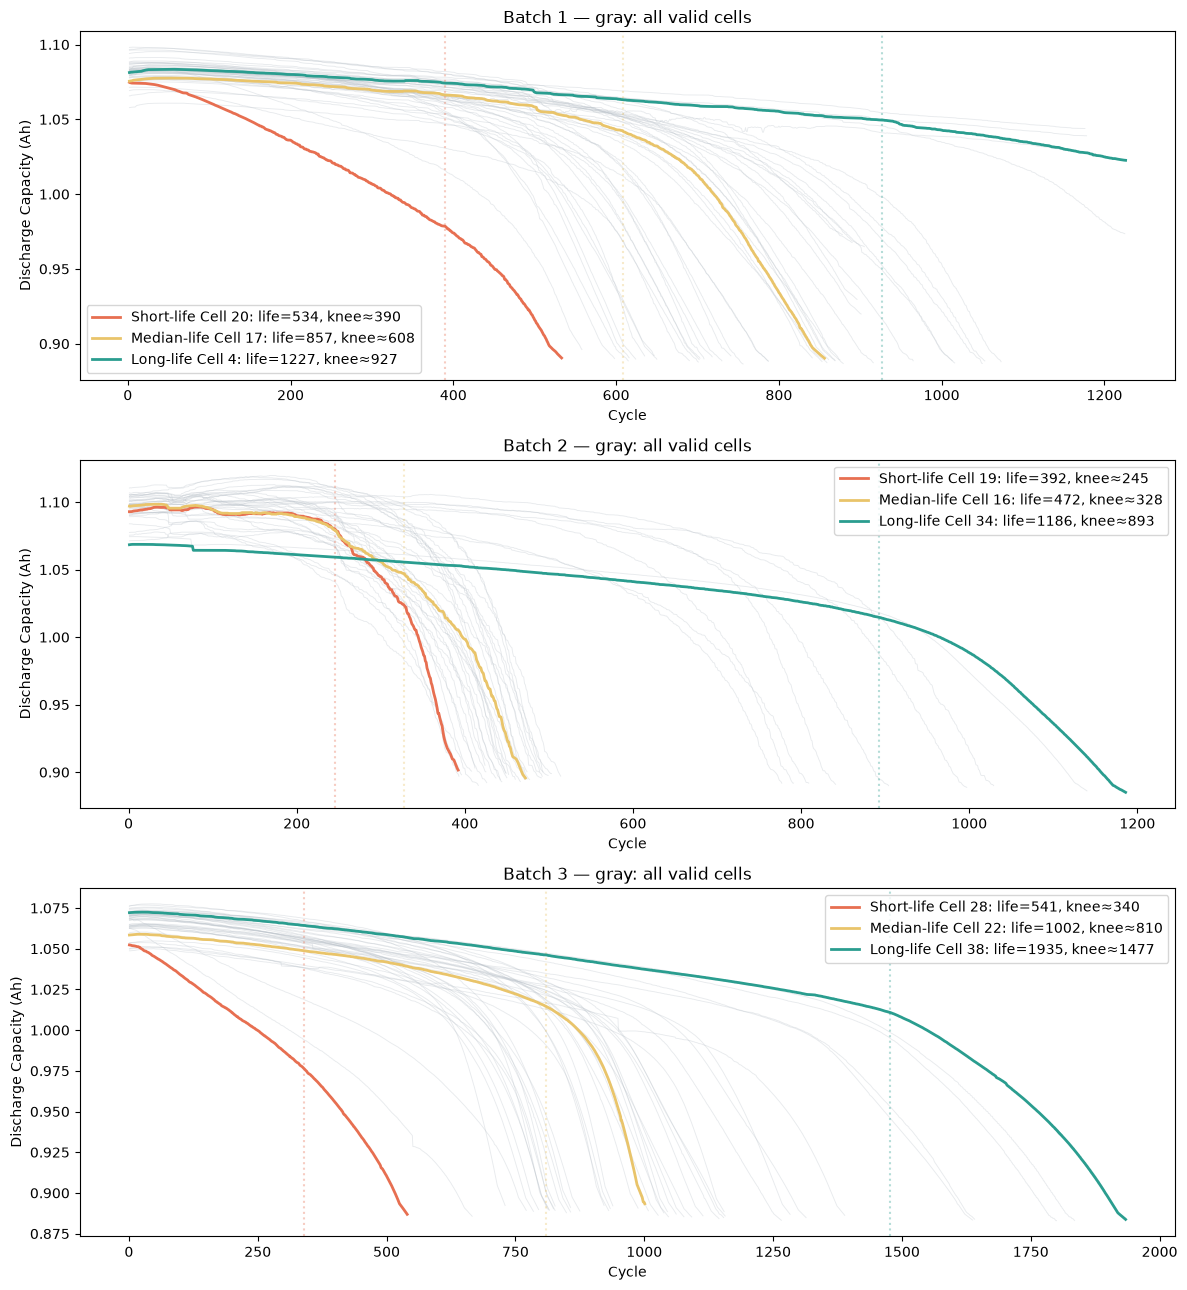

,cells_used,median_knee_cycle,median_knee_ratio,knee_life_spearman
batch,,,,
Batch 1,46,573.5,0.709,0.683
Batch 2,39,317.0,0.684,0.921
Batch 3,44,764.5,0.757,0.980


In [8]:
batch_knee_rows = []
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
representative_colors = ["#E76F51", "#E9C46A", "#2A9D8F"]
representative_names = ["Short-life", "Median-life", "Long-life"]

for ax, (batch_name, cell_group) in zip(axes, batch_cells.groupby("batch")):
    # 전체 셀을 먼저 표시해 대표 셀 선택으로 인해 전체 패턴이 가려지지 않도록 한다.
    for cell_id in cell_group["cell_id"].astype(int):
        all_sample = batch_summary[(batch_summary["batch"] == batch_name) &
                                   (batch_summary["cell_id"] == cell_id) &
                                   (batch_summary["QDischarge"] > 0)].sort_values("cycle").copy()
        all_sample["smooth_q"] = all_sample["QDischarge"].rolling(31, center=True, min_periods=5).median()
        ax.plot(all_sample["cycle"], all_sample["smooth_q"],
                color="#B8C0C8", linewidth=0.65, alpha=0.32, zorder=1)

    ordered = cell_group.sort_values("cycle_life")
    selected_ids = [int(ordered.iloc[0]["cell_id"]),
                    int(ordered.iloc[(len(ordered)-1)//2]["cell_id"]),
                    int(ordered.iloc[-1]["cell_id"])]
    for cell_id, rep_name, rep_color in zip(selected_ids, representative_names, representative_colors):
        sample = batch_summary[(batch_summary["batch"] == batch_name) &
                               (batch_summary["cell_id"] == cell_id) &
                               (batch_summary["QDischarge"] > 0)].sort_values("cycle").copy()
        life = int(cell_group.loc[cell_group["cell_id"] == cell_id, "cycle_life"].iloc[0])
        sample["smooth_q"] = sample["QDischarge"].rolling(31, center=True, min_periods=5).median()
        valid = sample.dropna(subset=["smooth_q"])
        x_norm = (valid["cycle"] - valid["cycle"].min()) / (valid["cycle"].max() - valid["cycle"].min())
        drop = valid["smooth_q"].iloc[0] - valid["smooth_q"].iloc[-1]
        y_norm = (valid["smooth_q"] - valid["smooth_q"].iloc[-1]) / drop
        knee_cycle = int(valid.loc[(y_norm - (1 - x_norm)).idxmax(), "cycle"])
        ax.plot(sample["cycle"], sample["smooth_q"], linewidth=2.0, color=rep_color,
                label=f"{rep_name} Cell {cell_id}: life={life}, knee≈{knee_cycle}", zorder=3)
        ax.axvline(knee_cycle, color=rep_color, alpha=0.35, linestyle=":", zorder=2)
    ax.set(title=f"{batch_name} — gray: all valid cells",
           xlabel="Cycle", ylabel="Discharge Capacity (Ah)")
    ax.legend()

for (batch_name, cell_id), sample in batch_summary[batch_summary["QDischarge"] > 0].groupby(["batch", "cell_id"]):
    sample = sample.sort_values("cycle").copy()
    sample["smooth_q"] = sample["QDischarge"].rolling(31, center=True, min_periods=5).median()
    valid = sample.dropna(subset=["smooth_q"])
    if len(valid) < 10:
        continue
    x_norm = (valid["cycle"] - valid["cycle"].min()) / (valid["cycle"].max() - valid["cycle"].min())
    drop = valid["smooth_q"].iloc[0] - valid["smooth_q"].iloc[-1]
    if not np.isfinite(drop) or drop <= 0:
        continue
    y_norm = (valid["smooth_q"] - valid["smooth_q"].iloc[-1]) / drop
    knee_cycle = int(valid.loc[(y_norm - (1 - x_norm)).idxmax(), "cycle"])
    life = float(batch_cells.loc[(batch_cells["batch"] == batch_name) &
                                 (batch_cells["cell_id"] == cell_id), "cycle_life"].iloc[0])
    batch_knee_rows.append({"batch": batch_name, "cell_id": cell_id,
                            "knee_cycle": knee_cycle, "cycle_life": life,
                            "knee_ratio": knee_cycle / life})
plt.tight_layout()
plt.show()
batch_knees = pd.DataFrame(batch_knee_rows)
display(batch_knees.groupby("batch").agg(
    cells_used=("cell_id", "count"),
    median_knee_cycle=("knee_cycle", "median"),
    median_knee_ratio=("knee_ratio", "median"),
    knee_life_spearman=("knee_cycle", lambda s: spearmanr(s, batch_knees.loc[s.index, "cycle_life"]).statistic),
).round(3))

### Question 2 — 해석 및 결론

#### 1. 열화곡선의 형태

전체 유효 셀의 방전용량 곡선을 확인한 결과, 용량은 일정한 속도로 감소하지 않았다. 대부분 초기에는 완만하게 감소하다가 셀별 Knee Point 이후 감소 속도가 커지는 비선형 열화 형태를 보였다.

회색 선은 전체 유효 셀이고, 색 선은 최단수명·중간수명·최장수명 셀의 대표 사례다. 대표 셀은 곡선 형태를 쉽게 비교하기 위해 강조했으며, Knee Point 통계량은 전체 셀을 사용해 계산했다.

#### 2. Batch별 특징

- **Batch 1:** 최단수명 Cell 20은 수명 534회, Knee 약 390회이며 초기부터 용량이 빠르게 감소한다. 최장수명 Cell 4는 수명 1,227회, Knee 약 927회로 완만한 열화 구간이 더 길다.
- **Batch 2:** Knee Cycle 중앙값이 317회로 가장 빠르다. 최단수명 Cell 19는 Knee가 약 245회지만, 최장수명 Cell 34는 약 893회로 같은 Batch 안에서도 큰 차이가 있다.
- **Batch 3:** Knee Cycle 중앙값이 764.5회로 가장 늦다. 최장수명 Cell 38은 수명 1,935회, Knee 약 1,477회로 가장 오랜 기간 방전용량을 유지한다.

전체 셀의 Knee Cycle 중앙값은 Batch 1이 573.5회, Batch 2가 317.0회, Batch 3이 764.5회다. Question 1에서 확인한 Batch별 수명 분포와 같은 방향이다.

#### 3. Knee Point와 수명의 관계

Knee Cycle과 Cycle Life의 Spearman 상관은 Batch 1 0.683, Batch 2 0.921, Batch 3 0.980으로 양의 관계를 보였다. 열화 가속이 늦게 시작되는 셀일수록 최종 수명도 긴 경향이 있다는 의미다.

Knee/Life 비율 중앙값은 약 0.684~0.757로, 대체로 최종 수명의 68~76% 부근에서 열화가 빨라졌다.

#### 4. 해석의 한계와 모델링 결정

Knee Point는 평활화된 열화곡선의 굽어짐을 이용해 계산한 근사값이므로 전기화학적으로 확정된 고장 시점은 아니다.

또한 Knee Point를 계산하려면 배터리의 전체 미래곡선이 필요하다. 따라서 수명과 강한 관계가 있더라도 초기 100사이클 예측 모델에 사용하면 미래정보 누출이 발생한다.

방전용량의 비선형 열화를 고려해 Day 2에서는 선형 회귀와 함께 Random Forest, Gradient Boosting도 비교한다. Knee Point는 현상 설명에만 사용하고 모델 입력에서는 제외한다.

#### 5. 최종 결론

방전용량은 초기에 완만하게 감소하다가 Knee Point 이후 감소 속도가 커지는 비선형 열화 형태를 보였다. Batch 2는 열화 가속이 가장 일찍 나타났고 Batch 3은 가장 늦게 나타나, Question 1에서 확인한 수명 분포와 일치했다.

Knee Point가 늦을수록 Cycle Life도 긴 경향이 있지만, 전체 미래곡선이 필요한 값이므로 초기 수명 예측 피처에서는 제외하고 열화 현상 설명에만 사용한다.

---

# Question 3. ΔQ(V) 곡선은 초기 사이클에서 차이가 보이는가?

Cycle 100과 Cycle 10의 Q(V) 차이를 전체 유효 셀에서 계산한다. 산점도와 상관계수는 전체 셀을 사용하고, 곡선 형태 비교에서는 겹침을 줄이기 위해 각 배치의 최단수명·최장수명 셀을 강조한다.

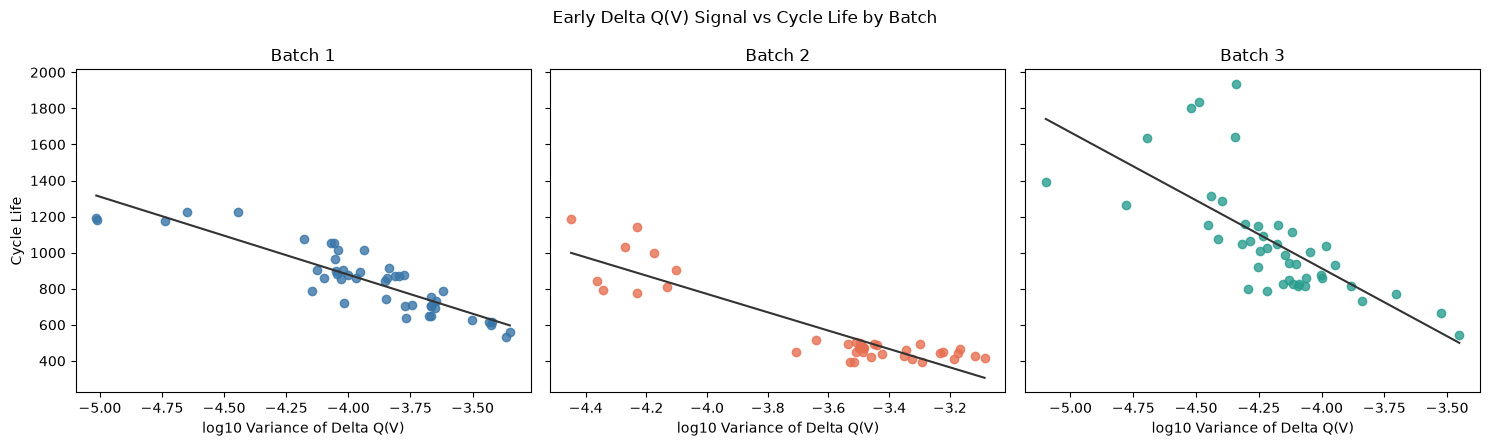

,batch,Spearman rho,p-value
0,Batch 1,-0.871,3.48e-15
1,Batch 2,-0.709,4.39e-07
2,Batch 3,-0.797,9.42e-11


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
deltaq_tests = []
for ax, (batch_name, group), color in zip(axes, batch_features.groupby("batch"), colors):
    x, y = group["log10_deltaq_variance"], group["cycle_life"]
    ax.scatter(x, y, color=color, alpha=0.8)
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    ax.plot(line_x, slope * line_x + intercept, color="#333333")
    result = spearmanr(x, y)
    deltaq_tests.append({"batch": batch_name, "Spearman rho": result.statistic,
                         "p-value": result.pvalue})
    ax.set(title=batch_name, xlabel="log10 Variance of Delta Q(V)")
axes[0].set_ylabel("Cycle Life")
fig.suptitle("Early Delta Q(V) Signal vs Cycle Life by Batch")
plt.tight_layout()
plt.show()
display(pd.DataFrame(deltaq_tests).style.format(
    {"Spearman rho": "{:.3f}", "p-value": "{:.2e}"}
))

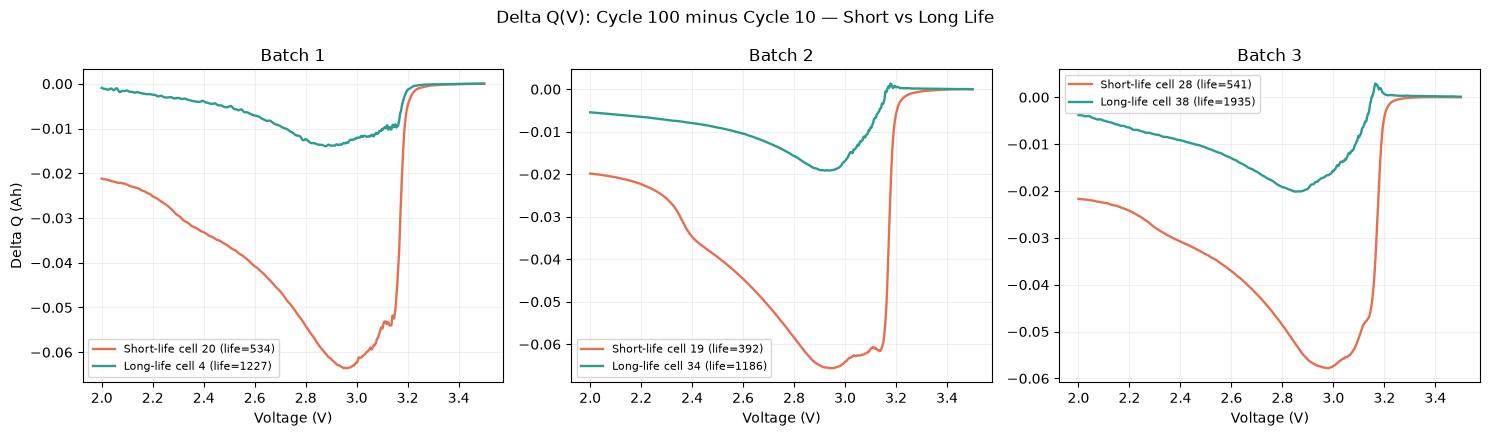

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
curve_colors = {"Short-life": "#E76F51", "Long-life": "#2A9D8F"}
for ax, (batch_name, group) in zip(axes, batch_cells.groupby("batch")):
    ordered = group.sort_values("cycle_life")
    selected = {"Short-life": ordered.iloc[0], "Long-life": ordered.iloc[-1]}
    for label, row in selected.items():
        cell_id = int(row["cell_id"])
        voltage, delta_q = deltaq_curves[(batch_name, cell_id)]
        ax.plot(voltage, delta_q, color=curve_colors[label], linewidth=1.7,
                label=f"{label} cell {cell_id} (life={int(row['cycle_life'])})")
    ax.set(title=batch_name, xlabel="Voltage (V)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.18)
axes[0].set_ylabel("Delta Q (Ah)")
fig.suptitle("Delta Q(V): Cycle 100 minus Cycle 10 — Short vs Long Life")
plt.tight_layout()
plt.show()

### Question 3 — 해석 및 결론

#### 1. ΔQ(V) 곡선 비교

Cycle 100과 Cycle 10의 Q(V) 차이를 비교한 결과, 세 Batch 모두 단수명 셀의 ΔQ(V) 변화 폭이 장수명 셀보다 크게 나타났다.

Batch 1의 단수명 Cell 20은 ΔQ(V)가 약 -0.06Ah까지 감소했지만, 장수명 Cell 4는 약 -0.014Ah 수준으로 변화 폭이 작았다. 이는 초기 100사이클 동안 Q(V) 곡선이 많이 변한 셀일수록 수명이 짧을 가능성을 보여준다.

곡선 비교는 형태를 쉽게 확인하기 위해 각 Batch의 최단수명·최장수명 셀을 사용했으며, 상관분석은 전체 유효 셀을 대상으로 수행하였다.

Batch 3에서는 단수명 Cell 28과 장수명 Cell 38의 ΔQ(V) 최저점이 각각 약 2.980V와 2.853V에서 나타나 곡선의 위치가 완전히 정렬되지 않았다. 따라서 특정 전압 한 지점의 차이보다 곡선 전체의 변화 크기를 요약하는 분산을 피처로 사용하였다.

#### 2. ΔQ(V) 분산과 Cycle Life의 관계

ΔQ(V) 곡선 전체를 하나의 수치로 요약하기 위해 분산을 계산하고 `log10`을 적용하였다.

`log10 ΔQ(V) 분산`과 Cycle Life의 Spearman 상관은 Batch 1 `-0.871`(p=`3.48e-15`), Batch 2 `-0.709`(p=`4.39e-07`), Batch 3 `-0.797`(p=`9.42e-11`)로 나타났다. 세 Batch 모두 강한 음의 관계를 보였고 p-value도 0.05보다 작았다.
따라서 ΔQ(V) 분산이 클수록 Cycle Life가 짧아지는 경향이 일관되게 나타났다.

`log10` 값은 음수이므로 0에 가까울수록 원래 분산이 크다. 예를 들어 -3은 -5보다 ΔQ(V) 변화가 크다.

#### 3. 해석의 한계와 모델링 결정

ΔQ(V)와 Cycle Life의 관계가 통계적으로 유의하더라도 ΔQ(V)가 수명 감소의 직접적인 원인이라고 단정할 수는 없다. ΔQ(V)는 배터리 내부에서 이미 진행된 초기 열화를 보여주는 예측 신호로 해석한다.

C-rate의 상관은 Batch별로 `-0.634 / +0.321 / -0.132`, 초기 평균 온도는 `-0.371 / +0.176 / +0.025`로 실제 방향이 달랐지만, ΔQ(V) 분산은 세 Batch에서 같은 방향의 관계를 유지했다. 또한 Cycle 10과 Cycle 100만 사용하므로 예측 시점에 계산할 수 있으며 미래정보 누출도 발생하지 않는다.

#### 4. 최종 결론

초기 100사이클 동안 ΔQ(V) 변화가 큰 셀일수록 최종 수명이 짧아지는 경향이 세 Batch에서 일관되게 확인되었다. 따라서 `log10 ΔQ(V) 분산`을 초기 배터리 수명 예측의 핵심 피처로 선택한다.

---

# Question 4. 충전 조건(C-rate)과 수명의 관계는?

두 단계 충전 정책을 80% SOC까지의 유효 C-rate로 환산해 배치별 수명 관계, 프로토콜별 평균 수명, 초기 ΔQ(V) 열화 신호와의 관계를 확인한다.

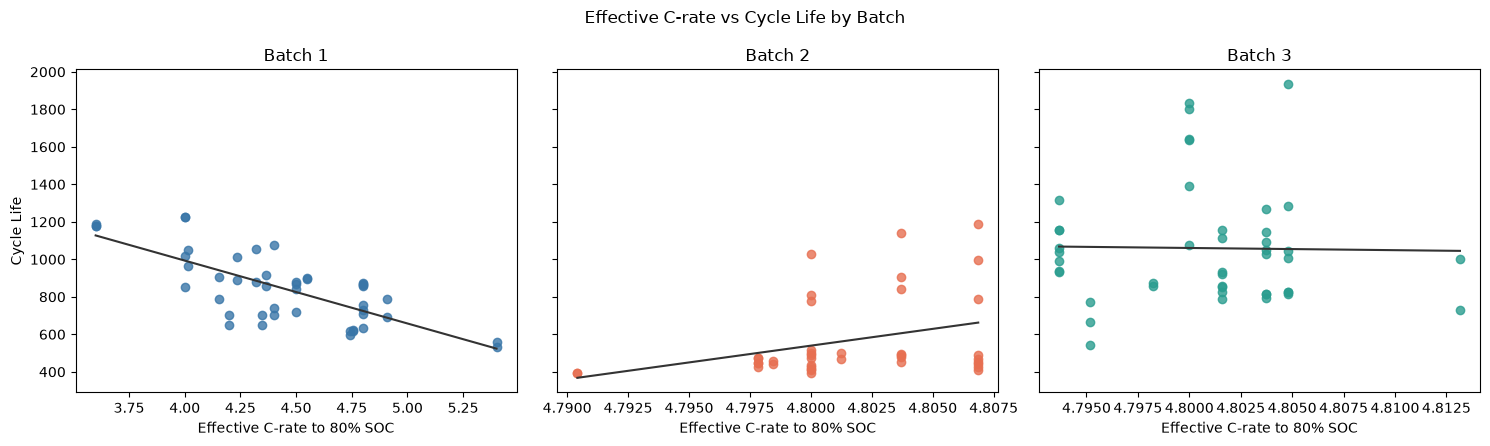

,batch,C-rate_min,C-rate_max,Spearman rho,p-value
0,Batch 1,3.600,5.400,-0.634,2.24e-06
1,Batch 2,4.790,4.807,0.321,4.65e-02
2,Batch 3,4.794,4.813,-0.132,3.93e-01


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
crate_tests = []
for ax, (batch_name, group), color in zip(axes, batch_features.groupby("batch"), colors):
    x, y = group["effective_c_rate_to_80pct"], group["cycle_life"]
    ax.scatter(x, y, color=color, alpha=0.8)
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    ax.plot(line_x, slope * line_x + intercept, color="#333333")
    result = spearmanr(x, y)
    crate_tests.append({"batch": batch_name,
                        "C-rate_min": x.min(), "C-rate_max": x.max(),
                        "Spearman rho": result.statistic, "p-value": result.pvalue})
    ax.set(title=batch_name, xlabel="Effective C-rate to 80% SOC")
axes[0].set_ylabel("Cycle Life")
fig.suptitle("Effective C-rate vs Cycle Life by Batch")
plt.tight_layout()
plt.show()
display(pd.DataFrame(crate_tests).style.format({
    "C-rate_min": "{:.3f}", "C-rate_max": "{:.3f}",
    "Spearman rho": "{:.3f}", "p-value": "{:.2e}"
}))

,batch,charging_policy,mean_cycle_life,cell_count
3,Batch 1,4C(80%)-4C,1226.5,2
0,Batch 1,3.6C(80%)-3.6C,1182.0,3
1,Batch 1,4.4C(80%)-4.4C,1074.0,1
20,Batch 1,8C(15%)-3.6C,1008.5,2
4,Batch 1,5.4C(40%)-3.6C,966.5,2
11,Batch 1,6C(30%)-3.6C,952.5,2
13,Batch 1,6C(40%)-3C,935.5,2
5,Batch 1,5.4C(50%)-3.6C,899.5,2
15,Batch 1,6C(50%)-3C,888.5,2
7,Batch 1,5.4C(60%)-3.6C,859.5,2


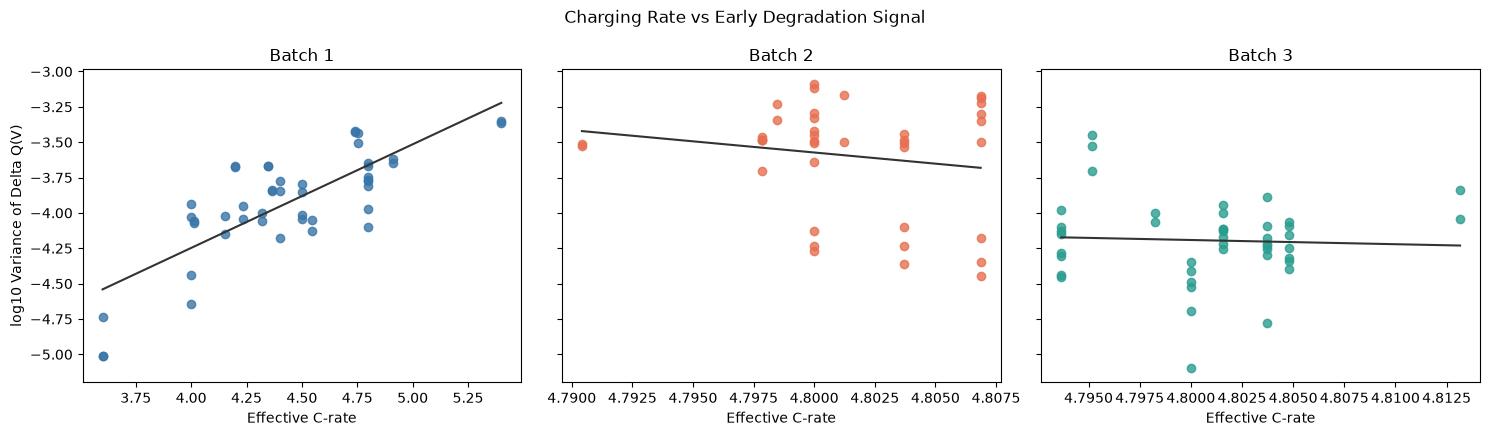

,batch,Spearman rho,p-value
0,Batch 1,0.670,3.44e-07
1,Batch 2,0.003,9.88e-01
2,Batch 3,0.031,8.43e-01


In [12]:
policy_life = (
    batch_cells.groupby(["batch", "charging_policy"])["cycle_life"]
    .agg(mean_cycle_life="mean", cell_count="count")
    .reset_index()
    .sort_values(["batch", "mean_cycle_life"], ascending=[True, False])
)
display(policy_life.round(1))

crate_degradation = batch_features[[
    "batch", "cell_id", "effective_c_rate_to_80pct", "log10_deltaq_variance"
]].copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
crate_deltaq_tests = []
for ax, (batch_name, group), color in zip(axes, crate_degradation.groupby("batch"), colors):
    x, y = group["effective_c_rate_to_80pct"], group["log10_deltaq_variance"]
    ax.scatter(x, y, color=color, alpha=0.8)
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    ax.plot(line_x, slope * line_x + intercept, color="#333333")
    result = spearmanr(x, y)
    crate_deltaq_tests.append({"batch": batch_name, "Spearman rho": result.statistic,
                               "p-value": result.pvalue})
    ax.set(title=batch_name, xlabel="Effective C-rate")
axes[0].set_ylabel("log10 Variance of Delta Q(V)")
fig.suptitle("Charging Rate vs Early Degradation Signal")
plt.tight_layout()
plt.show()
display(pd.DataFrame(crate_deltaq_tests).style.format(
    {"Spearman rho": "{:.3f}", "p-value": "{:.2e}"}
))

### Question 4 — 해석 및 결론

#### 1. C-rate와 Cycle Life의 관계

Batch 1의 유효 C-rate 범위는 3.60~5.40C이며 Cycle Life와 Spearman `-0.634`의 음의 관계를 보였다. p-value는 `2.24e-06`으로, Batch 1에서는 충전 속도가 높을수록 수명이 짧아지는 경향이 확인되었다.

Batch 2는 Spearman `+0.321`, p-value `0.0465`로 0.05 기준에서 유의한 양의 관계를 보였으며, 이는 초기 가설과 반대 방향이다. 다만 C-rate 범위가 4.790~4.807C로 약 0.017C에 불과하고 여러 피처와 Batch를 탐색한 결과이므로 충전 속도의 일반적인 효과로 해석하기 어렵다. 다른 실험 조건이나 표본 구성의 영향을 배제할 수 없다.

Batch 3은 C-rate 범위가 4.794~4.813C로 좁고 Spearman `-0.132`, p-value `0.393`으로 유의한 관계가 확인되지 않았다.

#### 2. 충전 정책별 평균 수명과 예외

Batch 1에서 3.6C 정책의 평균 수명은 1,182.0사이클, 4.0C는 1,226.5사이클, 4.8C는 753.0사이클, 5.4C는 546.5사이클이다.

전체적으로 높은 C-rate에서 평균 수명이 짧아지는 경향이 있지만, 4.0C가 3.6C보다 오래가는 예외가 존재한다. 같은 4.8C 정책에서도 셀 수명이 636회와 870회로 달라 충전 속도만으로 개별 셀의 수명을 설명할 수 없다.

#### 3. C-rate와 초기 열화 신호

C-rate와 `log10 ΔQ(V) 분산`의 Spearman 상관은 Batch 1에서 `+0.670`으로 나타났다. Batch 1에서는 충전 속도가 높을수록 초기 ΔQ(V) 변화도 커지는 경향이 있다는 의미다.

Batch 2와 Batch 3의 상관은 각각 `+0.003`, `+0.031`로 거의 0이다. 두 배치에서는 C-rate의 관측 범위가 매우 좁아 초기 열화와의 관계를 구분하기 어렵다.

#### 4. 해석의 한계와 모델링 결정

Batch 1의 결과는 초기 가설을 지지하지만, 이를 고속 충전이 수명 감소의 직접적인 원인이라는 의미로 해석할 수는 없다. 충전 정책별 표본 수가 작고 다른 실험 조건이 함께 영향을 미쳤을 가능성이 있기 때문이다.

C-rate는 Batch 1에서는 유용한 신호지만 세 Batch에서 일관된 관계를 보이지 않아 보조 피처로 사용한다. ΔQ(V) 단독 모델과 비교하여 Batch 1 검증 MAPE를 개선할 때만 최종 피처에 포함한다.

#### 5. 최종 결론

고속 충전과 단수명의 관계는 C-rate 범위가 충분한 Batch 1에서 확인되었지만 Batch 2·3에는 일반화되지 않았다. 따라서 충전 속도만으로 배터리 수명을 판단하지 않고, ΔQ(V)와 온도 등 다른 초기 신호를 함께 검토한다.

---

# Question 5. 어떤 신호가 수명과 연관되어 있는가?

ΔQ(V), C-rate, 초기 온도, 초기 내부저항과 Cycle Life의 Spearman 상관관계를 배치별로 비교하고, 피처 간 멀티콜리니어리티를 확인한다.

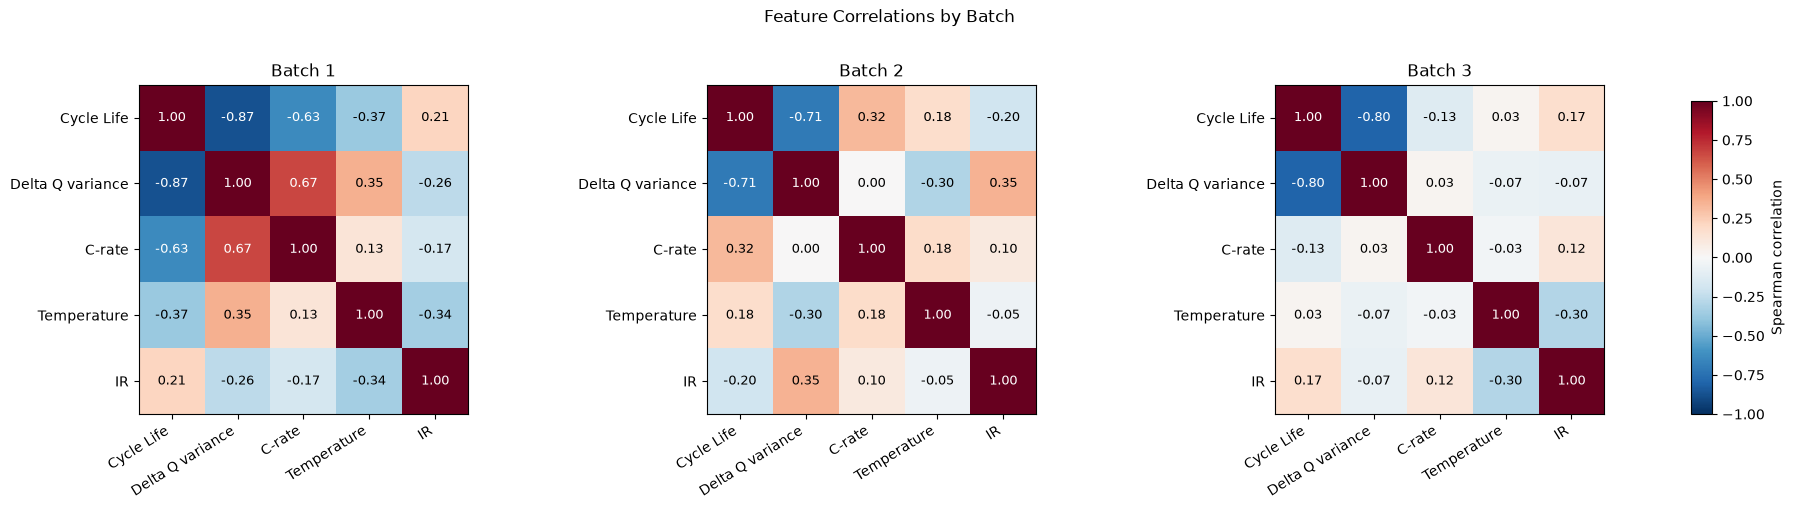

batch,Batch 1,Batch 2,Batch 3
feature,,,
C-rate,-0.634,0.321,-0.132
Delta Q variance,-0.871,-0.709,-0.797
IR,0.212,-0.200,0.171
Temperature,-0.371,0.176,0.025


,batch,feature,Spearman rho,p-value
0,Batch 1,Delta Q variance,-0.871,3.48e-15
1,Batch 1,C-rate,-0.634,2.24e-06
2,Batch 1,Temperature,-0.371,1.10e-02
3,Batch 1,IR,0.212,1.57e-01
4,Batch 2,Delta Q variance,-0.709,4.39e-07
5,Batch 2,C-rate,0.321,4.65e-02
6,Batch 2,Temperature,0.176,2.84e-01
7,Batch 2,IR,-0.200,2.64e-01
8,Batch 3,Delta Q variance,-0.797,9.42e-11
9,Batch 3,C-rate,-0.132,3.93e-01


,batch,strongest_feature_pair,Spearman rho
0,Batch 1,Delta Q variance ↔ C-rate,0.670
1,Batch 2,Delta Q variance ↔ IR,0.351
2,Batch 3,Temperature ↔ IR,-0.295


In [13]:
corr_columns = ["cycle_life", "log10_deltaq_variance", "effective_c_rate_to_80pct",
                "mean_Tavg_first100", "median_IR_first100"]
corr_labels = ["Cycle Life", "Delta Q variance", "C-rate", "Temperature", "IR"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))
target_corr_rows = []
multicollinearity_rows = []
for ax, (batch_name, group) in zip(axes, batch_features.groupby("batch")):
    matrix = group[corr_columns].corr(method="spearman")
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(5), corr_labels, rotation=32, ha="right")
    ax.set_yticks(range(5), corr_labels)
    ax.set_title(batch_name)
    for row in range(5):
        for col in range(5):
            value = matrix.iloc[row, col]
            ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                    color="white" if abs(value) > 0.55 else "black", fontsize=9.5)
    for feature, label in zip(corr_columns[1:], corr_labels[1:]):
        result = spearmanr(group[feature], group["cycle_life"], nan_policy="omit")
        target_corr_rows.append({"batch": batch_name, "feature": label,
                                 "Spearman rho": result.statistic, "p-value": result.pvalue})
    feature_matrix = matrix.iloc[1:, 1:].copy()
    feature_values = feature_matrix.to_numpy(copy=True)
    np.fill_diagonal(feature_values, np.nan)
    row_idx, col_idx = np.unravel_index(
        np.nanargmax(np.abs(feature_values)), feature_values.shape
    )
    multicollinearity_rows.append({
        "batch": batch_name,
        "strongest_feature_pair": f"{corr_labels[row_idx+1]} ↔ {corr_labels[col_idx+1]}",
        "Spearman rho": feature_values[row_idx, col_idx],
    })
fig.subplots_adjust(left=0.06, right=0.92, bottom=0.23, top=0.84, wspace=0.38)
cbar_ax = fig.add_axes([0.945, 0.23, 0.012, 0.58])
fig.colorbar(image, cax=cbar_ax, label="Spearman correlation")
fig.suptitle("Feature Correlations by Batch", y=0.98)
plt.show()

target_correlations = pd.DataFrame(target_corr_rows)
display(target_correlations.pivot(index="feature", columns="batch", values="Spearman rho").round(3))
display(target_correlations.style.format({"Spearman rho": "{:.3f}", "p-value": "{:.2e}"}))
display(pd.DataFrame(multicollinearity_rows).round(3))

### Question 5 — 해석 및 결론

#### 1. 초기 피처와 Cycle Life의 관계

`log10 ΔQ(V) 분산`은 Cycle Life와 Batch 1 `-0.871`, Batch 2 `-0.709`, Batch 3 `-0.797`의 강한 음의 상관을 보였다. 세 Batch에서 관계의 방향이 일관되므로 가장 신뢰할 수 있는 초기 수명 신호로 판단하였다.

C-rate는 Batch 1에서 `-0.634`의 관계를 보였지만 Batch 2·3에서는 관계가 약하거나 방향이 달랐다. 초기 평균 온도와 내부저항도 Batch별 관계가 일관되지 않았다.

#### 2. 데이터 품질과 피처 선택

Batch 2의 내부저항 0값은 4,286/22,064행으로 전체의 19.43%이다. 이를 실제 저항이 아닌 측정 누락으로 판단했으며, 내부저항은 관계도 약하고 데이터 품질 문제도 있어 초기 핵심 피처에서 제외하였다.

C-rate와 온도는 일부 Batch에서 수명과 관계를 보이므로 보조 피처 후보로 유지한다.

#### 3. 멀티콜리니어리티 확인

Batch 1에서 C-rate와 ΔQ(V) 분산은 `+0.670`의 상관을 보였다. 두 피처를 함께 사용하면 일부 중복된 정보가 포함될 수 있으므로 Ridge와 ElasticNet을 이용해 회귀계수의 안정성을 확인한다.

#### 4. 해석의 한계와 모델링 결정

상관관계는 피처와 수명이 함께 움직이는 경향을 나타낼 뿐 직접적인 원인을 의미하지 않는다. 따라서 최종 피처 채택 여부는 상관계수만으로 결정하지 않고 Batch 1 교차검증과 Hold-out MAPE를 비교하여 판단한다.

#### 5. 최종 결론

ΔQ(V) 분산을 핵심 피처로 선택하고 C-rate와 초기 평균 온도는 보조 후보로 비교한다. 내부저항은 관계의 일관성과 데이터 품질이 부족해 우선 제외하며, 피처 간 중복 가능성을 고려해 정규화 회귀모델과 비선형 모델을 함께 검증한다.

---

## Modeling Strategy

### 1. Target과 입력 피처

- **Target:** 연속형 `cycle_life`
- **핵심 피처:** `log10 ΔQ(V) 분산`
- **보조 후보:** 유효 C-rate, 초기 100사이클 평균 온도
- **제외 피처:** 내부저항은 관계의 일관성과 데이터 품질이 부족해 우선 제외
- **미래정보 제외:** Knee Point는 전체 열화곡선이 필요하므로 모델 입력에서 제외

`batch`는 학습·테스트 데이터를 구분하는 변수, `charging_policy`는 그룹 분할 변수, `cell_id`는 식별자로 사용하며 모델 입력에는 포함하지 않는다.

### 2. 피처 조합

| 구성 | 피처 | 비교 목적 |
|---|---|---|
| A | ΔQ(V) 분산 | 핵심 피처 단독 성능 |
| B | A + C-rate | 충전 조건의 추가 효과 |
| C | A + 초기 평균 온도 | 온도 정보의 추가 효과 |
| D | A + C-rate + 온도 | 전체 피처 조합의 성능과 과적합 여부 |

ΔQ(V) 단독 모델을 기준으로 두고, C-rate와 온도를 추가했을 때 검증 MAPE가 실제로 개선되는지 확인한다.

### 3. 후보 모델

- **Dummy Regressor:** 모델이 넘어야 할 최소 기준
- **Linear Regression:** ΔQ(V)와 수명의 기본적인 선형 관계 확인
- **Ridge / ElasticNet:** 피처 간 중복과 작은 표본에서 계수 안정화
- **Random Forest:** 비선형 관계와 피처 상호작용 확인
- **Gradient Boosting:** 이전 예측의 잔차를 순차적으로 보완

표본 수가 작으므로 트리 깊이와 리프 크기를 제한하고, 딥러닝은 과적합 위험과 해석의 어려움 때문에 사용하지 않는다.

### 4. 데이터 분할과 검증

- **Train:** Batch 1의 학습 영역
- **Cross-Validation:** 충전 정책을 그룹으로 사용한 GroupKFold
- **Valid:** Batch 1의 정책 그룹 Hold-out
- **Test:** 모델과 피처를 확정한 뒤 Batch 2에서 한 번만 평가
- **Batch 3:** 필요할 경우 추가 일반화 평가

같은 충전 정책이 학습과 검증에 동시에 포함되지 않도록 그룹 단위로 분할한다. Batch 2 결과를 확인한 뒤 모델이나 피처를 다시 선택하지 않는다.

### 5. 모델 선택 기준

최종 모델은 다음 기준으로 결정한다.

1. Dummy Regressor보다 MAPE가 낮은가?
2. GroupKFold 평균 MAPE와 fold별 편차가 안정적인가?
3. Batch 1 Hold-out MAPE가 낮은가?
4. 교차검증과 Hold-out 성능 차이가 지나치게 크지 않은가?
5. 보조 피처를 추가했을 때 ΔQ(V) 단독 모델보다 성능이 실제로 개선되는가?
6. 성능이 비슷하면 구조가 단순하고 해석하기 쉬운 모델을 우선하는가?

### 6. 평가 지표와 예상 위험

- **주지표:** MAPE
- **보조지표:** MAE, RMSE, R²
- **비교 기준:** 원논문 Target MAPE 9.1%
- **추가 확인:** 실제값-예측값 그래프와 잔차분석

Batch 2는 단수명 셀이 많아 동일한 절대오차에서도 MAPE가 크게 나타날 수 있다. 또한 Batch 1과 목표분포가 다르므로 Valid-Test Gap과 과대·과소 예측 방향을 함께 확인한다.

## 우선 검증 모델과 예상 선택 방향

Day 1 EDA 결과를 기준으로 Ridge Regression을 1차 우선 후보로 검증한다.

`log10 ΔQ(V) 분산`은 세 Batch에서 Cycle Life와 강하고 일관된 음의 관계를 보였으며, Batch 1의 표본 수가 46개로 작다. 또한 Batch 1에서 ΔQ(V) 분산과 C-rate 사이에 `+0.670`의 상관이 있어 피처를 함께 사용할 경우 계수 불안정 가능성이 있다. Ridge는 작은 표본과 피처 간 중복에 대응하면서 결과를 비교적 쉽게 해석할 수 있다.

배터리 열화곡선에서 비선형 형태가 확인되었으므로 Gradient Boosting을 주요 비교 후보로 둔다. Batch 1 GroupKFold와 Hold-out에서 두 모델의 MAPE와 성능 차이를 비교한다.

성능이 비슷하면 구조가 단순하고 해석이 쉬운 Ridge를 선택하고, Gradient Boosting이 일관되게 더 낮은 MAPE와 안정적인 Gap을 보이면 Gradient Boosting을 선택한다.

이는 EDA를 근거로 설정한 예상이며, 최종 모델은 Day 2의 Batch 1 검증 결과를 확인한 뒤 확정한다.